In [66]:
from pandas import read_csv
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

In [67]:
df = read_csv("../../datasets/heart-disease.csv")

# This dataset contains non numeric values. see previous lessons.
index_to_delete = []

for i in range(df.shape[0]):
    for j in range(14):
        if str(df.iloc[i].iloc[j]) == '?':
            print("found non numeric value in %ith column and %ith row"%(i, j))
            index_to_delete.append(i)
            
ndf = df.drop(index=index_to_delete).reset_index()
x = np.asarray(ndf[['age', 'sex', 'chest pain type', 'resting blood presure',
       'serum cholestoral', 'fasting blood sugar > 120 mg/dl',
       'resting electrocardiographic results', 'maximum heart rate achieved',
       'exercise induced angina',
       'ST depression induced by exercise relative to rest',
       'the slope of the peak exercise ST segment',
       'number of major vessels (0-3) colored by flourosopy', 'thal']].values)

x = preprocessing.StandardScaler().fit(x).transform(x)
y = np.asarray(ndf['diagnosis of heart disease'].values)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=4)
print("training data: ", x_train.shape, y_train.shape)
print("testing data: ", x_test.shape, y_test.shape)

found non numeric value in 87th column and 12th row
found non numeric value in 166th column and 11th row
found non numeric value in 192th column and 11th row
found non numeric value in 266th column and 12th row
found non numeric value in 287th column and 11th row
found non numeric value in 302th column and 11th row
training data:  (207, 13) (207,)
testing data:  (90, 13) (90,)


In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
LogReg = LogisticRegression(C=0.01, solver='liblinear').fit(x_train, y_train)
# C is used to decrease overfit.
LogReg

LogisticRegression(C=0.01, solver='liblinear')

In [75]:
yhat = LogReg.predict(x_test)
print(yhat[0:6])
print(y_test[0:6])

[1 0 0 1 0 1]
[1 0 1 1 0 1]


In [70]:
yhat_prob = LogReg.predict_proba(x_test)
# There are 5 type of diagnose. 0,1,2,3,4. it shows probability of each of them.
yhat_prob[0:6]

array([[0.41584787, 0.58415213],
       [0.55953821, 0.44046179],
       [0.5556653 , 0.4443347 ],
       [0.17452528, 0.82547472],
       [0.74405715, 0.25594285],
       [0.44457919, 0.55542081]])

In [73]:
from sklearn.metrics import jaccard_score as js
from sklearn import metrics
print("acc score: %f"%(metrics.accuracy_score(y_test, yhat)))
print("f1 score: %f"%(metrics.f1_score(y_test, yhat, average='micro')))
print("Jac score for 0: %f"%(js(y_test, yhat, average='micro', labels=[0])))
print("Jac score for 1: %f"%(js(y_test, yhat, average='micro', labels=[1])))

acc score: 0.833333
f1 score: 0.833333
Jac score for 0: 0.705882
Jac score for 1: 0.722222


In [72]:
print(metrics.classification_report(y_test, yhat))

              precision    recall  f1-score   support

           0       0.80      0.86      0.83        42
           1       0.87      0.81      0.84        48

    accuracy                           0.83        90
   macro avg       0.83      0.83      0.83        90
weighted avg       0.84      0.83      0.83        90



In [83]:
cm = metrics.confusion_matrix(y_test, yhat)
cm

array([[36,  6],
       [ 9, 39]], dtype=int64)

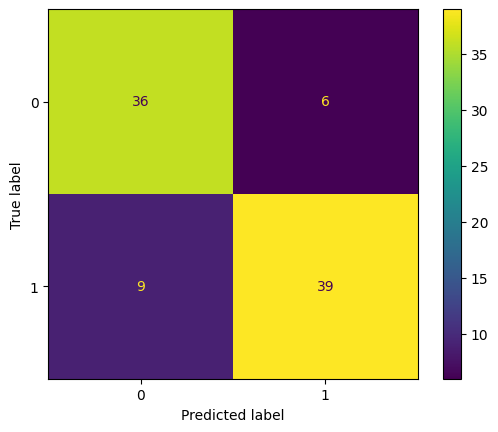

In [82]:
disp = metrics.ConfusionMatrixDisplay(cm)
disp.plot()


In [ ]:
# As you see the best results for this dataset are gaind from KNN prediction methode!